In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

sns.set_theme(style="whitegrid")

# Chargement des données brutes
print("Chargement des données...")
df_brut = pd.read_csv('/kaggle/input/datasets/victorchen004/datascience/export.csv', parse_dates=['horodate'])

# Paramètres choisis par l'utilisateur
CLIENT_CHOISI = df_brut['id'].unique()[0] # On prend le 1er client par défaut, ou mettre un ID spécifique
JOURS_A_PREDIRE = 14 # Par exemple, on veut prédire les 2 prochaines semaines

print(f"Préparation des données pour le client : {CLIENT_CHOISI}")

# Filtrage sur le client sélectionné
df_client = df_brut[df_brut['id'] == CLIENT_CHOISI].copy()

# On force Pandas à comprendre que c'est une date en gérant le fuseau horaire (utc=True)
df_client['horodate'] = pd.to_datetime(df_client['horodate'], utc=True)

# Resampling : On passe d'un pas de 30 minutes à une consommation quotidienne
df_client.set_index('horodate', inplace=True)
# On additionne toutes les demi-heures d'une même journée avec resample('D').sum()
df_jour = df_client[['valeur']].resample('D').sum()

print(f"Historique disponible : {len(df_jour)} jours.")
df_jour.head(1)

Chargement des données...
Préparation des données pour le client : 476866365062
Historique disponible : 365 jours.


,valeur
horodate,
2023-10-31 00:00:00+00:00,1568.8
2023-11-01 00:00:00+00:00,31949.0
2023-11-02 00:00:00+00:00,32165.9
2023-11-03 00:00:00+00:00,90896.0
2023-11-04 00:00:00+00:00,66983.7


,valeur
horodate,
2023-10-31 00:00:00+00:00,1568.8
2023-11-01 00:00:00+00:00,31949.0
2023-11-02 00:00:00+00:00,32165.9
2023-11-03 00:00:00+00:00,90896.0
2023-11-04 00:00:00+00:00,66983.7
2023-11-05 00:00:00+00:00,40389.2
2023-11-06 00:00:00+00:00,31245.8
2023-11-07 00:00:00+00:00,31195.0
2023-11-08 00:00:00+00:00,31856.2


In [10]:
# Création des variables de décalage (Lags)
df_features = df_jour.copy()

# Consommation des jours précédents
df_features['J-1'] = df_features['valeur'].shift(1) # Hier
df_features['J-2'] = df_features['valeur'].shift(2) # Avant-hier
df_features['J-7'] = df_features['valeur'].shift(7) # Le même jour la semaine dernière

# Information sur le jour de la semaine (0 = Lundi, 6 = Dimanche)
df_features['jour_semaine'] = df_features.index.dayofweek

# On supprime les 7 premières lignes car elles contiennent des "NaN" 
df_features.dropna(inplace=True)

display(df_features.head(10))

,valeur,J-1,J-2,J-7,jour_semaine
horodate,,,,,
2023-11-07 00:00:00+00:00,31195.0,31245.8,40389.2,1568.8,1
2023-11-08 00:00:00+00:00,31856.2,31195.0,31245.8,31949.0,2
2023-11-09 00:00:00+00:00,29058.2,31856.2,31195.0,32165.9,3
2023-11-10 00:00:00+00:00,25883.7,29058.2,31856.2,90896.0,4
2023-11-11 00:00:00+00:00,27600.7,25883.7,29058.2,66983.7,5
2023-11-12 00:00:00+00:00,26692.7,27600.7,25883.7,40389.2,6
2023-11-13 00:00:00+00:00,20263.4,26692.7,27600.7,31245.8,0
2023-11-14 00:00:00+00:00,21417.1,20263.4,26692.7,31195.0,1
2023-11-15 00:00:00+00:00,24765.9,21417.1,20263.4,31856.2,2


In [11]:
# On sépare les caractéristiques (X) de la cible à prédire (y)
X = df_features.drop(columns=['valeur'])
y = df_features['valeur']

# On garde les X derniers jours pour tester notre modèle 
# (X = le nombre de jours à prédire
split_index = len(df_features) - JOURS_A_PREDIRE

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

print(f"Taille du jeu d'entraînement : {len(X_train)} jours")
print(f"Taille du jeu de test : {len(X_test)} jours")

Taille du jeu d'entraînement : 344 jours
Taille du jeu de test : 14 jours


In [12]:
# Initialisation et entraînement du modèle
modele_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modele_rf.fit(X_train, y_train)

print("Modèle entraîné avec succès !")

Modèle entraîné avec succès !


In [13]:
# On récupère la dernière ligne connue de notre jeu d'entraînement pour initialiser le processus
dernier_jour_connu = df_features.iloc[split_index - 1].copy()

predictions_futures = []
historique_recent = list(y_train.iloc[-7:].values) # Les 7 derniers jours réels

# Boucle pour prédire jour par jour
for i in range(JOURS_A_PREDIRE):
    # On prépare les features du jour à prédire
    features_du_jour = pd.DataFrame([{
        'J-1': historique_recent[-1],
        'J-2': historique_recent[-2],
        'J-7': historique_recent[-7],
        # On calcule quel jour de la semaine on sera
        'jour_semaine': (dernier_jour_connu.name + pd.Timedelta(days=i+1)).dayofweek 
    }])
    
    # 2. Le modèle fait sa prédiction pour ce jour
    pred_jour = modele_rf.predict(features_du_jour)[0]
    predictions_futures.append(pred_jour)
    
    # 3. On met à jour notre historique pour la boucle suivante (ajouter la prédiction)
    historique_recent.append(pred_jour)
    historique_recent.pop(0) # On enlève le jour le plus vieux pour garder une fenêtre de 7 jours

# On stocke les résultats dans un tableau
dates_futures = y_test.index
df_resultats = pd.DataFrame({
    'Date': dates_futures,
    'Consommation_Reelle': y_test.values,
    'Prediction': predictions_futures
}).set_index('Date')

# Calcul de l'erreur moyenne
mae = mean_absolute_error(df_resultats['Consommation_Reelle'], df_resultats['Prediction'])
print(f"Erreur Absolue Moyenne (MAE) : {mae:.2f} kWh par jour en moyenne de décalage")

Erreur Absolue Moyenne (MAE) : 7218.16 kWh par jour en moyenne de décalage


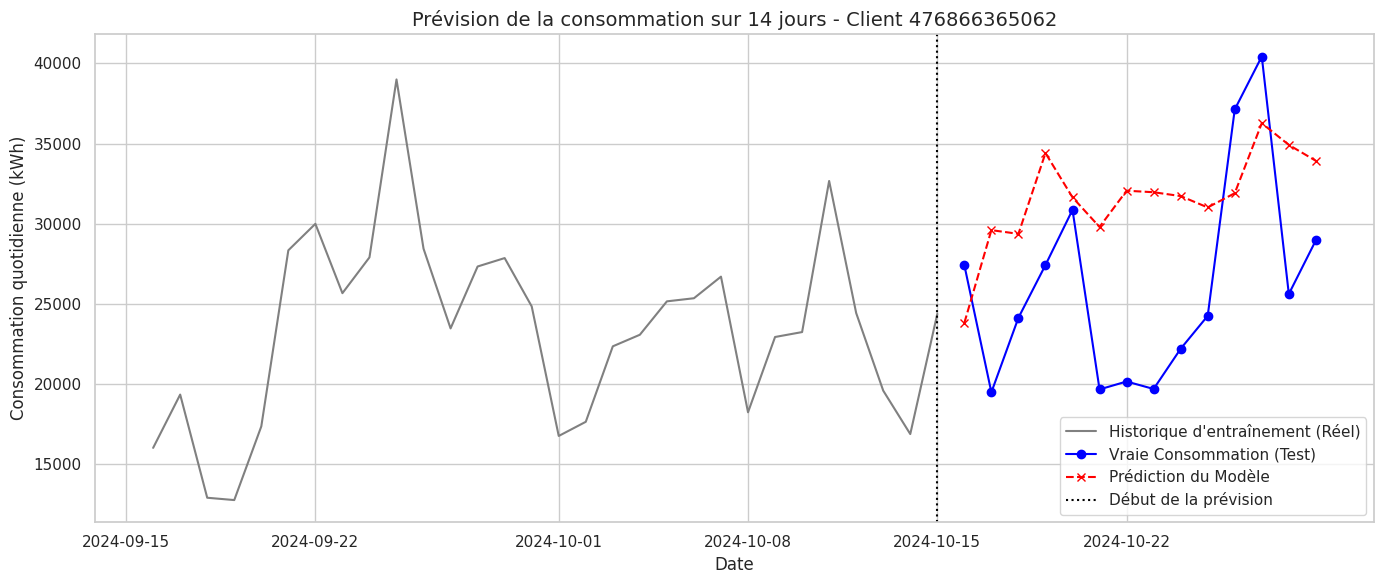

In [14]:
plt.figure(figsize=(14, 6))

# On trace une partie de l'historique d'entraînement (ex les 30 derniers jours) pour le contexte
plt.plot(y_train.index[-30:], y_train.values[-30:], label='Historique d\'entraînement (Réel)', color='gray')

# On trace la vraie consommation des jours testés
plt.plot(df_resultats.index, df_resultats['Consommation_Reelle'], label='Vraie Consommation (Test)', color='blue', marker='o')

# On trace la prédiction du modèle
plt.plot(df_resultats.index, df_resultats['Prediction'], label='Prédiction du Modèle', color='red', linestyle='--', marker='x')

plt.axvline(x=y_train.index[-1], color='black', linestyle=':', label='Début de la prévision')

plt.title(f"Prévision de la consommation sur {JOURS_A_PREDIRE} jours - Client {CLIENT_CHOISI}", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Consommation quotidienne (kWh)")
plt.legend()
plt.tight_layout()
plt.show()

--- Modèle : RÉSEAU DE NEURONES MLP ---


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


Réseau de Neurones entraîné !
Erreur Absolue Moyenne (Réseau de Neurones) : 5067.05 kWh/jour


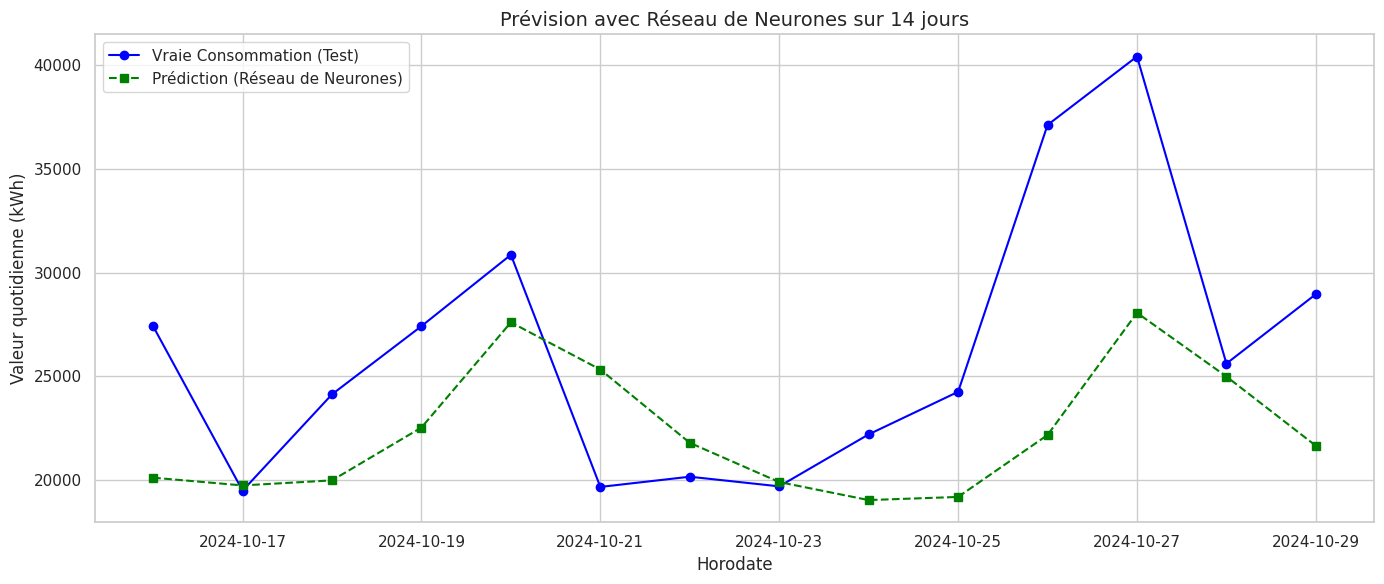

In [16]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

print("--- Modèle : RÉSEAU DE NEURONES MLP ---")

# NORMALISATION
scaler = StandardScaler()
# On apprend l'échelle sur le train, et on la transforme
X_train_scaled = scaler.fit_transform(X_train) 
# On transforme aussi le test avec la même échelle
X_test_scaled = scaler.transform(X_test)       

# ENTRAÎNEMENT DU MODÈLE
modele_nn = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=2000, random_state=42)
modele_nn.fit(X_train_scaled, y_train)
print("Réseau de Neurones entraîné !")

# PRÉDICTION ITÉRATIVE
dernier_jour_connu = df_features.iloc[split_index - 1].copy()
predictions_futures_nn = []
historique_recent = list(y_train.iloc[-7:].values) 

for i in range(JOURS_A_PREDIRE):
    # A : On construit les variables brutes du jour
    features_du_jour = pd.DataFrame([{
        'J-1': historique_recent[-1],
        'J-2': historique_recent[-2],
        'J-7': historique_recent[-7],
        'jour_semaine': (dernier_jour_connu.name + pd.Timedelta(days=i+1)).dayofweek 
    }])
    
    # B : On normalise ces données avant de prédire
    features_du_jour_scaled = scaler.transform(features_du_jour)
    
    # C : Prédiction
    pred_jour = modele_nn.predict(features_du_jour_scaled)[0]
    predictions_futures_nn.append(pred_jour)
    
    # D : Mise à jour de l'historique
    historique_recent.append(pred_jour)
    historique_recent.pop(0)

# RÉSULTATS ET COMPARAISON
df_resultats_nn = pd.DataFrame({
    'Date': y_test.index,
    'Valeur_Reelle': y_test.values,
    'Prediction_NN': predictions_futures_nn
}).set_index('Date')

mae_nn = mean_absolute_error(df_resultats_nn['Valeur_Reelle'], df_resultats_nn['Prediction_NN'])
print(f"Erreur Absolue Moyenne (Réseau de Neurones) : {mae_nn:.2f} kWh/jour")

# VISUALISATION
plt.figure(figsize=(14, 6))

# On trace les vraies valeurs
plt.plot(df_resultats_nn.index, df_resultats_nn['Valeur_Reelle'], label="Vraie Consommation (Test)", color='blue', marker='o')

# On trace les prédictions du Réseau de Neurones
plt.plot(df_resultats_nn.index, df_resultats_nn['Prediction_NN'], label="Prédiction (Réseau de Neurones)", color='green', linestyle='--', marker='s')

plt.title(f"Prévision avec Réseau de Neurones sur {JOURS_A_PREDIRE} jours", fontsize=14)
plt.xlabel("Horodate")
plt.ylabel("Valeur quotidienne (kWh)")
plt.legend()
plt.tight_layout()
plt.show()